### Overview


Embeddings are a way to compress large amounts of information into a smaller set of features that represent meaningful semantics. Instead of raw pixel values, each location is represented by a dense vector that captures the semantic content of the landscape. [AlphaEarth Foundations (AEF) Embeddings](https://aef-loader.readthedocs.io/en/latest/) is an openly available global dataset of satellite embeddings derived from multiple earth observation datasets, accessible via [Source Cooperative](https://source.coop/). The [`aef-loader`](https://aef-loader.readthedocs.io/en/latest/) package provides a convenient Python interface to query and stream these embeddings without downloading the entire dataset.

Embeddings can be used as input features to the classification model and results in higher accuracy outputs We will perform supervised land cover classification of AEF Embeddings using a Random Forest classifier and generate a classified image for the chosen region of interest.

### Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
if 'google.colab' in str(get_ipython()):
    !pip install rioxarray scikit-learn aef-loader dask[distributed]
    # Due to version conflict, you maybe prompted to
    # restart the runtime after the installation
    # After restarting proceed to run the cell below

In [ ]:
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Import Patch from matplotlib.patches
import numpy as np
import os
import pandas as pd
import rioxarray as rxr
import xarray as xr
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import asyncio
from aef_loader import AEFIndex, VirtualTiffReader, DataSource
from aef_loader.utils import dequantize_aef, reproject_datatree
from odc.geo.geobox import GeoBox
from pyproj import Transformer

In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.



In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Training Data

The training data is a set of Ground Control Points (GCPs) — point features, each labeled with a land cover class. We load the GeoJSON file with GeoPandas.

In [ ]:
gcps = (
    'https://storage.googleapis.com/spatialthoughts-public-data/'
    'python-remote-sensing/bangalore_gcps.geojson'
)
gcp_gdf = gpd.read_file(gcps)
gcp_gdf.head()

In [ ]:
gcp_gdf['landcover'].value_counts(sort=False)

In [ ]:
aoi_file_path = 'https://storage.googleapis.com/spatialthoughts-public-data/' \
  'bangalore.geojson'
aoi_gdf = gpd.read_file(aoi_file_path)
geometry = aoi_gdf.geometry.union_all()
geometry

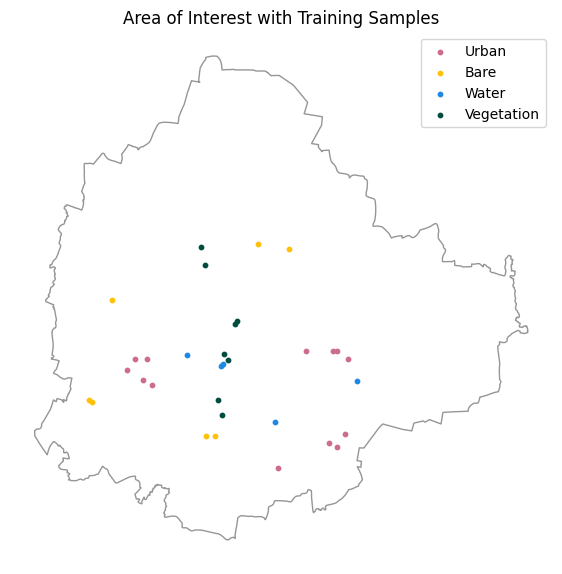

In [26]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7,7)
aoi_gdf.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#969696')

class_colors = {
    0: '#cc6d8f', # Urban
    1: '#ffc107', # Bare
    2: '#1e88e5', # Water
    3: '#004d40', # Vegetation
}

class_names = {
    0: 'Urban',
    1: 'Bare',
    2: 'Water',
    3: 'Vegetation'
}

# Plot the GCPs
for class_label, group in gcp_gdf.groupby('landcover'):
    group.plot(
        ax=ax,
        color=class_colors.get(class_label, 'red'),
        markersize=10,
        label=class_names.get(class_label, f'Unknown Class {class_label}')
    )

ax.legend(loc='upper right')
ax.set_title('Area of Interest with Training Samples')
ax.set_axis_off()
plt.show()

### Load the Satellite Embeddings

We now use the `aef-loader` package to load all the matching tiles of AlphaEarth Foundations Satellite Embeddings from Source Cooperative for the chosen year. This Lazily load the tiles as a XArray DataArray that we can fetch and process in chunks using Dask.

Create a `odc.geo.geobox.GeoBox` object which is a representation of the bounding box with a specific CRS and pixel grid.

In [ ]:
year = 2024
bbox = geometry.bounds
target_crs = 'EPSG:3857'

In [ ]:

# Transform bbox from EPSG:4326 to chosen crs
transformer = Transformer.from_crs('EPSG:4326', target_crs, always_xy=True)
x_min, y_min = transformer.transform(bbox[0], bbox[1])
x_max, y_max = transformer.transform(bbox[2], bbox[3])

geobox = GeoBox.from_bbox(
    bbox=(x_min, y_min, x_max, y_max),
    crs=target_crs,
    resolution=10,
)

In [ ]:
index = AEFIndex(source=DataSource.SOURCE_COOP)
await index.download()

# Query for tiles
tiles = await index.query(
    bbox=bbox,
    years=(year),
)
# Load tiles organized by UTM zone
async with VirtualTiffReader() as reader:
    tree = await reader.open_tiles_by_zone(tiles)

# Depending on the region, there maybe multiple
# tiles spanning different UTM zones
# Reproject all the tiles to the target GeoBox
# with the chosen projection and pixel resolution
combined = reproject_datatree(tree, target_geobox=geobox)
embeddings = combined.embeddings
embeddings

The embeddings are saved as 8-bit integer values to save space. We use the `dequantize_aef` helper function provided by `aef-loader` to convert them to the original 32-bit floating point values.

In [ ]:
embeddings_year = embeddings.isel(time=0)
embeddings_float = dequantize_aef(embeddings_year)
embeddings_float

We reproject the training points to match the composite CRS, then overlay them on an RGB preview of the composite. This lets us verify that the training points cover the expected land cover types.

### Extract Embeddings at Training Samples



In [ ]:
# Extract longitude and latitude from gcp_gdf
gcp_lon = gcp_gdf.geometry.x.values
gcp_lat = gcp_gdf.geometry.y.values

# Transform GCP coordinates to the target CRS (EPSG:3857)
# 'transformer' was defined previously in cell 'zjbO4zJ-CFOf'
gcp_x_coords, gcp_y_coords = transformer.transform(gcp_lon, gcp_lat)

# Create xarray DataArrays for indexing with a 'gcp_id' dimension
# This dimension will match the order of the gcp_gdf for easy association
gcp_ids = np.arange(len(gcp_gdf))

gcp_embeddings = embeddings_float.sel(
    x=xr.DataArray(gcp_x_coords, dims='gcp_id'),
    y=xr.DataArray(gcp_y_coords, dims='gcp_id'),
    method='nearest'
)

# Add landcover labels as a coordinate to the extracted embeddings
gcp_embeddings = gcp_embeddings.assign_coords(
    landcover=('gcp_id', gcp_gdf['landcover'].values)
)

# Display the extracted embeddings for verification
gcp_embeddings

In [ ]:
%%time
gcp_embeddings = gcp_embeddings.compute()

### Train a Classifier

We can now train a classifier with these extracted features. Scikit-learn has a wide-array of classifiers that we can choose from. For most remote sensing applications, [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) is the preferred classifier. However, a good choice for low-shot classification (classification using a very small number of examples, like our example), is [k-Nearest Neighbors (kNN)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). In a kNN classification, labeled examples are used to “partition” or cluster the embedding space, assigning a label for each pixel based on the label(s) of its closest neighbor(s) in the embedding space. Embeddings lend themselves very well to such partitioning. Let’s train a kNN classifier with our training data

In [ ]:
# Prepare the data for the classifier
X = gcp_embeddings.values.T # Transpose to have (n_samples, n_features)
y = gcp_embeddings['landcover'].values

# Initialize the KNeighborsClassifier
# Using n_neighbors=5 as a common starting point
classifier = KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=1)

# Train the classifier
classifier.fit(X, y)

### Classify the Image


In [ ]:
import dask.array as da

# Get embeddings as dask array: (bands, y, x)
# `embeddings_float` is an xarray DataArray, so `embeddings_float.data` gives the Dask array
emb_dask = embeddings_float.data

# Transpose to (y, x, bands) then reshape to (y*x, bands)
# dask.array.moveaxis is used for dask arrays
emb_dask = da.moveaxis(emb_dask, 0, -1)  # (y, x, bands)
ny, nx, nb = emb_dask.shape
emb_2d_dask = emb_dask.reshape(-1, nb)  # (y*x, bands)

# Rechunk so each block has ALL bands (axis 1 = single chunk)
# This is crucial for applying the classifier which expects all features for each sample
emb_2d_rechunked = emb_2d_dask.rechunk({0: 'auto', 1: -1})

# Define the prediction function to be mapped over Dask blocks
def predict_block(block, classifier_model):
    """Predict landcover class for one chunk of pixels."""
    # The classifier expects (n_samples, n_features)
    return classifier_model.predict(block)

# Map the prediction function over dask blocks
# The output will be a 1D array of class labels
predicted_labels_1d = emb_2d_rechunked.map_blocks(
    predict_block,
    classifier_model=classifier, # Pass the trained classifier
    dtype=np.int32,  # Output dtype will be integer class labels
    drop_axis=1,     # The bands axis is collapsed after prediction
)

# Reshape the 1D predictions back to the original 2D (y, x) shape
predicted_labels_2d = predicted_labels_1d.reshape(ny, nx)

# Convert to an xarray DataArray for easier handling and plotting
# Align coordinates with the original embeddings_float
predicted_landcover = xr.DataArray(
    predicted_labels_2d,
    coords={
        'y': embeddings_float.y,
        'x': embeddings_float.x
    },
    dims=['y', 'x'],
    name='predicted_landcover'
)
predicted_landcover

In [ ]:
%%time
# Compute the predicted landcover map
predicted_landcover_map = predicted_landcover.compute()
predicted_landcover_map

In [ ]:
import numpy as np

predicted_landcover_map = predicted_landcover_map.rio.write_crs(embeddings_float.rio.crs)

# Convert to float32 to allow NaN as nodata, as landcover values are integers anyway
predicted_landcover_map = predicted_landcover_map.astype(np.float32)
predicted_landcover_map = predicted_landcover_map.rio.write_nodata(embeddings_float.rio.nodata)

# Ensure valid geometry before reprojecting
valid_aoi_gdf = aoi_gdf.make_valid()
aoi_gdf_reprojected = valid_aoi_gdf.to_crs(embeddings_float.rio.crs)

# Clip the predicted landcover map. Now use np.nan as nodata for float dtype.
predicted_landcover_clipped = predicted_landcover_map.rio.clip(
    aoi_gdf_reprojected)
# Explicitly set the nodata attribute on the clipped DataArray
predicted_landcover_clipped = predicted_landcover_clipped.rio.write_nodata(np.nan)

predicted_landcover_clipped

### Visualize the Classification

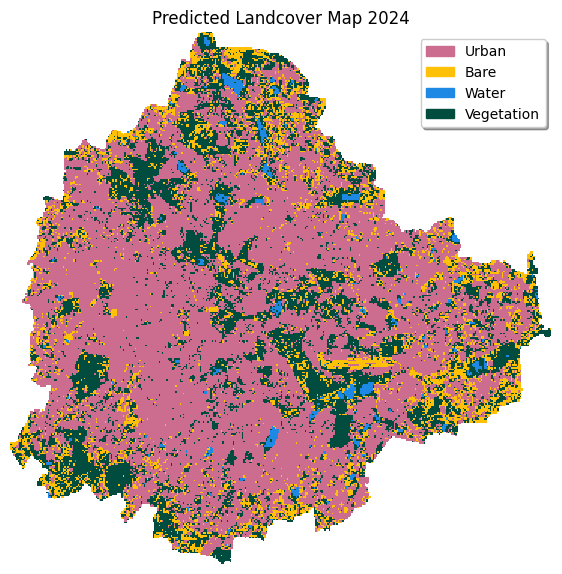

In [25]:
# Create a custom colormap from the defined class_colors
# Ensure the colors are in order of the class labels (0, 1, 2, 3)
sorted_class_labels = sorted(class_colors.keys())
colors_for_colormap = [class_colors[label] for label in sorted_class_labels]
cmap = mcolors.ListedColormap(colors_for_colormap)

# Set the color for nodata values (often internally represented as NaN after operations)
# to be transparent. This will hide the clipped-out areas.
cmap.set_bad(alpha=0)

# Define the normalization for the colorbar to align with integer classes
# Boundaries should be num_classes + 1, centered around the integers
boundaries = [i - 0.5 for i in range(len(sorted_class_labels) + 1)]
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(7, 7)

# Reproject the already clipped predicted_landcover_clipped for preview
# The .rio.nodata attribute on predicted_landcover_clipped will be respected by plot.imshow
preview = predicted_landcover_clipped.rio.reproject(
    predicted_landcover_clipped.rio.crs,
    resolution=100
)

# Plot the predicted landcover map using the custom colormap
preview.plot.imshow(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False # Remove the default colorbar
)

ax.set_title(f'Predicted Landcover Map {year}')
ax.set_axis_off()
ax.set_aspect('equal')

# Create a custom legend
legend_patches = []
for class_label in sorted_class_labels:
    color = class_colors[class_label]
    name = class_names[class_label]
    legend_patches.append(mpatches.Patch(color=color, label=name))

# Add the legend to the plot
ax.legend(
    handles=legend_patches,
    loc='upper right', # Changed to upper right
    ncol=1, # Changed to 1 class per row
    fancybox=True,
    shadow=True
)

plt.show()

### Save Classified Image

We finally save the results as a local Cloud-Optimized GeoTIFF file.

Rather than saving it to the temporary machine where Colab is running, we can save it to our own Google Drive. This will ensure the image will be available to us even after existing Google Colab.

Run the following cell to authenticate and mount the Google Drive.

In [ ]:
if 'google.colab' in str(get_ipython()):
  from google.colab import drive
  drive.mount('/content/drive')

In [ ]:
if 'google.colab' in str(get_ipython()):
  drive_folder_root = 'MyDrive'
  output_folder = 'data'
  output_folder_path = os.path.join(
      '/content/drive', drive_folder_root, output_folder)

  # Check if Google Drive is mounted
  if not os.path.exists('/content/drive'):
      print("Google Drive is not mounted. Please run the cell above to mount your drive.")
  else:
      if not os.path.exists(output_folder_path):
          os.makedirs(output_folder_path)
else:
  # Use the local folder
  output_folder_path = output_folder

In [ ]:
output_file = f'classification_{year}.tif'
output_path = os.path.join(output_folder_path, output_file)
predicted_landcover_clipped.rio.to_raster(output_path, driver='COG')
print(f'Wrote {output_path}')